Entregable 1
Data Engineering


Importaciones

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas

Lectura csv

In [37]:
imdb = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/entregable1/bmw_pricing_v3.csv")

In [38]:
imdb

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,BMW,218 Gran Tourer,39743.0,110.0,NaN,diesel,black,NaN,False,True,False,NaN,False,False,True,False,14600.0,2018-08-01
4839,BMW,218 Active Tourer,49832.0,100.0,2015-06-01,diesel,grey,NaN,False,True,False,NaN,False,False,True,True,17500.0,2018-08-01
4840,BMW,218 Gran Tourer,19633.0,110.0,2015-10-01,diesel,grey,van,False,True,False,NaN,False,False,True,True,17000.0,2018-09-01
4841,BMW,218 Active Tourer,27920.0,110.0,2016-04-01,diesel,brown,van,True,True,False,False,False,False,True,True,22700.0,2018-09-01


Vista inicial

In [39]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

Inicio ejercicio
1. ¿Qué columnas eliminaron inicialmente del dataset y por qué?



Creamos copia del original

In [40]:
imdb2=imdb.copy()

In [41]:
imdb[imdb.duplicated(keep=False)] #Comprobamos que el dataset no tiene duplicados

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta


In [42]:
imdb.isnull().sum() #Vemos los nulos que tenemos

,0
marca,970
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486


Elimino columnas innecesarias.

In [43]:
imdb = imdb.drop(columns=['asientos_traseros_plegables', 'marca' ])  ##Para eliminar en Pandas usamos drop

In [10]:
#1a acción: elimino filas con precio NULO. Es mi target.
imdb = imdb.dropna(subset=["precio"])

In [44]:
imdb.shape

(4843, 16)

Comprobación

In [45]:
imdb[imdb.duplicated(keep=False)] #Comprobamos que el dataset no tiene duplicados

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta


In [46]:
imdb.isnull().sum() #Vemos los nulos que tenemos

,0
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486
camara_trasera,2


In [47]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   modelo                4840 non-null   object 
 1   km                    4841 non-null   float64
 2   potencia              4842 non-null   float64
 3   fecha_registro        2420 non-null   object 
 4   tipo_gasolina         4838 non-null   object 
 5   color                 4398 non-null   object 
 6   tipo_coche            3383 non-null   object 
 7   volante_regulable     4839 non-null   object 
 8   aire_acondicionado    4357 non-null   object 
 9   camara_trasera        4841 non-null   object 
 10  elevalunas_electrico  4841 non-null   object 
 11  bluetooth             4115 non-null   object 
 12  gps                   4843 non-null   bool   
 13  alerta_lim_velocidad  4115 non-null   object 
 14  precio                4837 non-null   float64
 15  fecha_venta          

2. Manejo de nulos, explicar qué se hizo con los nulos por cada columna


In [48]:
imdb.isnull().any()

,0
modelo,True
km,True
potencia,True
fecha_registro,True
tipo_gasolina,True
color,True
tipo_coche,True
volante_regulable,True
aire_acondicionado,True
camara_trasera,True


In [49]:
imdb.isnull().sum() #Num de nulos en cada variable

,0
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486
camara_trasera,2


In [17]:
# Primero, eliminar las columnas mencionadas en el Paso 1 (si no se hizo ya)
# Asumimos que df ya solo contiene las columnas restantes.

# 1. Eliminar filas con nulos en el Target (precio)
imdb.dropna(subset=['precio'], inplace=True)

# 2. Imputación de variables booleanas/categóricas con 'False'
columnas_no_imputar = ['bluetooth', 'alerta_lim_velocidad', 'aire_acondicionado']
for col in columnas_no_imputar:
    imdb[col].fillna('False', inplace=True)

# 3. Imputación de variables categóricas restantes con la Moda
columnas_moda_imputar = ['tipo_coche', 'color']
for col in columnas_moda_imputar:
    # Se debe verificar si la columna existe antes de imputar,
    # ya que 'marca' y 'modelo' han sido eliminadas.
    if col in imdb.columns:
        moda_col = imdb[col].mode()[0]
        imdb[col].fillna(moda_col, inplace=True)

# 4. Eliminación de nulos residuales en el resto de columnas (numéricas y otras categóricas)
imdb.dropna(inplace=True)

# Verificar (opcional)
print("Conteo de nulos después del preprocesamiento:")
print(imdb.isnull().sum().sort_values(ascending=False).head())

Conteo de nulos después del preprocesamiento:
modelo           0
km               0
potencia         0
tipo_gasolina    0
color            0
dtype: int64


/tmp/ipython-input-3591354530.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  imdb[col].fillna('No', inplace=True)
/tmp/ipython-input-3591354530.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

 3. Análisis univariable, explicar alguna información interesante encontrada

Distribucion precio

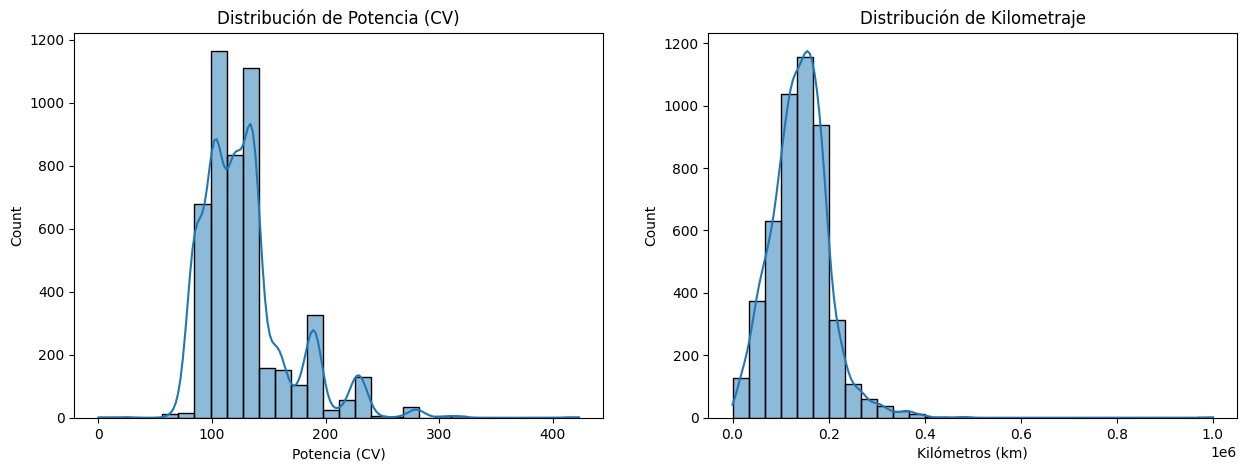

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 5))

# 1. Potencia (Concentración en rango medio)
plt.subplot(1, 2, 1)
sns.histplot(imdb['potencia'], bins=30, kde=True)
plt.title('Distribución de Potencia (CV)')
plt.xlabel('Potencia (CV)')

# 2. Kilometraje (Concentración en valores bajos)
plt.subplot(1, 2, 2)
sns.histplot(imdb['km'], bins=30, kde=True)
plt.title('Distribución de Kilometraje')
plt.xlabel('Kilómetros (km)')
plt.show()

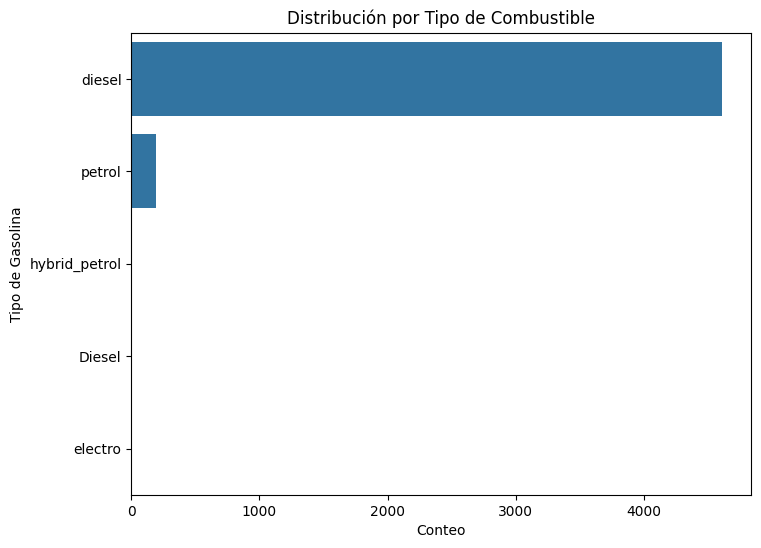

In [19]:
#Tipo de gaolina
plt.figure(figsize=(8, 6))
sns.countplot(y='tipo_gasolina', data=imdb, order=imdb['tipo_gasolina'].value_counts().index)
plt.title('Distribución por Tipo de Combustible')
plt.xlabel('Conteo')
plt.ylabel('Tipo de Gasolina')
plt.show()



Colores

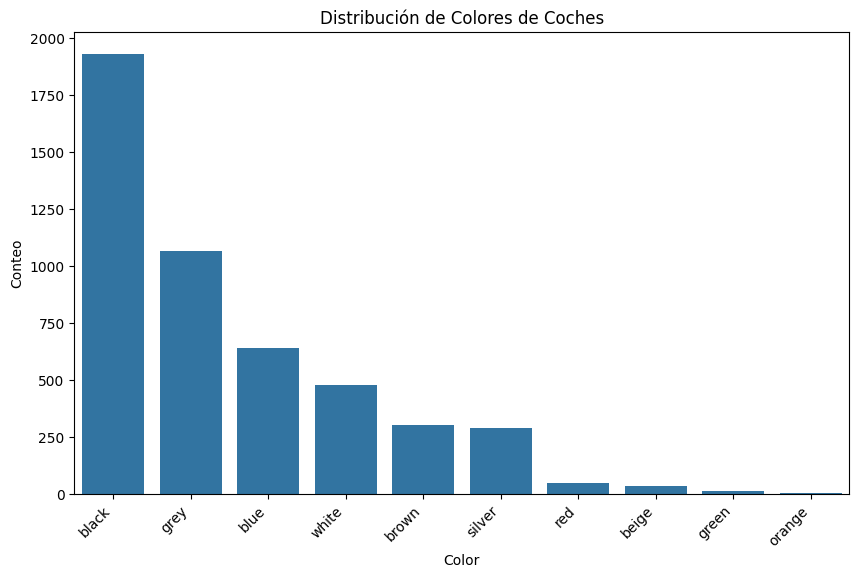

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='color', data=imdb, order=imdb['color'].value_counts().index)
plt.title('Distribución de Colores de Coches')
plt.xlabel('Color')
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.show()

4. Matriz de correlación inicial

La columna 'antigüedad' no existe en el DataFrame actual y será omitida.
La columna 'consumo' no existe en el DataFrame actual y será omitida.
La columna 'emisiones' no existe en el DataFrame actual y será omitida.

Correlación de Pearson con 'precio':
precio      1.000000
potencia    0.639254
km         -0.410189
Name: precio, dtype: float64


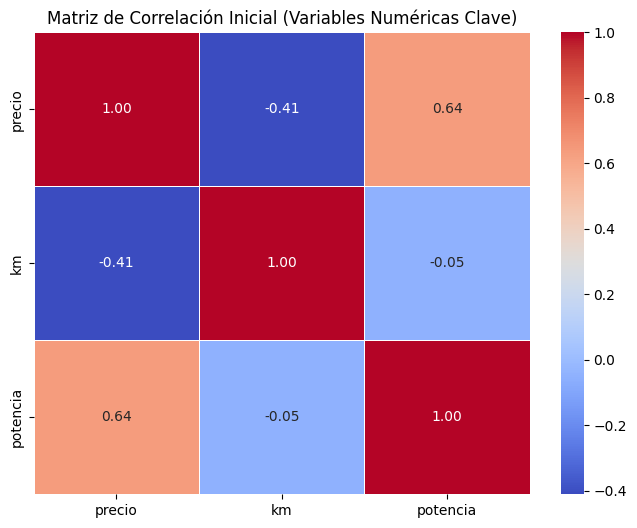

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir las variables que se desea correlacionar:
# 'precio', 'km' y 'potencia' son variables que sabemos que existen y son cruciales.
columnas_correlacion = ['precio', 'km', 'potencia']

# Variables opcionales mencionadas en el análisis que pueden haber sido eliminadas o no existir:
variables_opcionales = ['antigüedad', 'consumo', 'emisiones']

# 2. Verificar la existencia de las variables opcionales e incluirlas si existen.
for col in variables_opcionales:
    if col in imdb2.columns:
        columnas_correlacion.append(col)
    else:
        print(f"La columna '{col}' no existe en el DataFrame actual y será omitida.")

# 3. Crear la matriz de correlación solo con las columnas existentes
matriz_correlacion = imdb2[columnas_correlacion].corr()

# 4. Imprimir los valores de correlación con 'precio' para cuantificar
print("\nCorrelación de Pearson con 'precio':")
# Mostramos la correlación de todas las variables seleccionadas con el precio.
print(matriz_correlacion['precio'].sort_values(ascending=False))

# 5. Visualizar la matriz de correlación con un Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion,
            annot=True,     # Muestra el valor del coeficiente
            cmap='coolwarm',
            fmt=".2f",      # Formato a dos decimales
            linewidths=.5)  # Líneas de separación
plt.title('Matriz de Correlación Inicial (Variables Numéricas Clave)')
plt.show()

5. Variable vs target

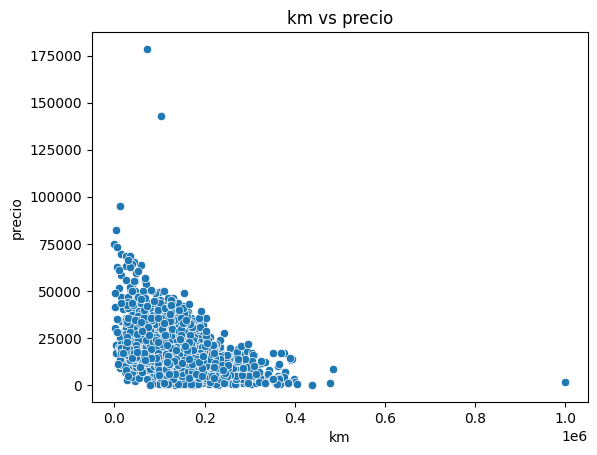

In [24]:
sns.scatterplot(data=imdb, x='km', y='precio')
plt.title("km vs precio")
plt.show()


potencia vs precio

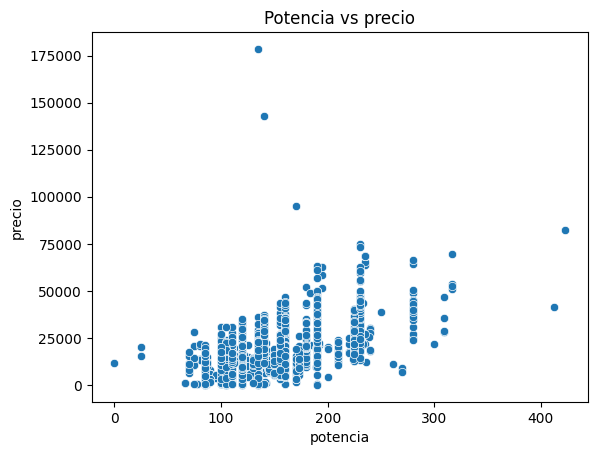

In [25]:
sns.scatterplot(data=imdb, x='potencia', y='precio')
plt.title("Potencia vs precio")
plt.show()


6. Transformación de categóricas

In [26]:
imdb = pd.get_dummies(imdb,
                      columns=[ 'tipo_gasolina', 'color', 'tipo_coche'],
                      drop_first=True)

7. Escalado con MinMaxScaler + correlación final

escalada

Iniciando limpieza y conversión estricta...
Limpieza de datos completada.
Variables escaladas con éxito.


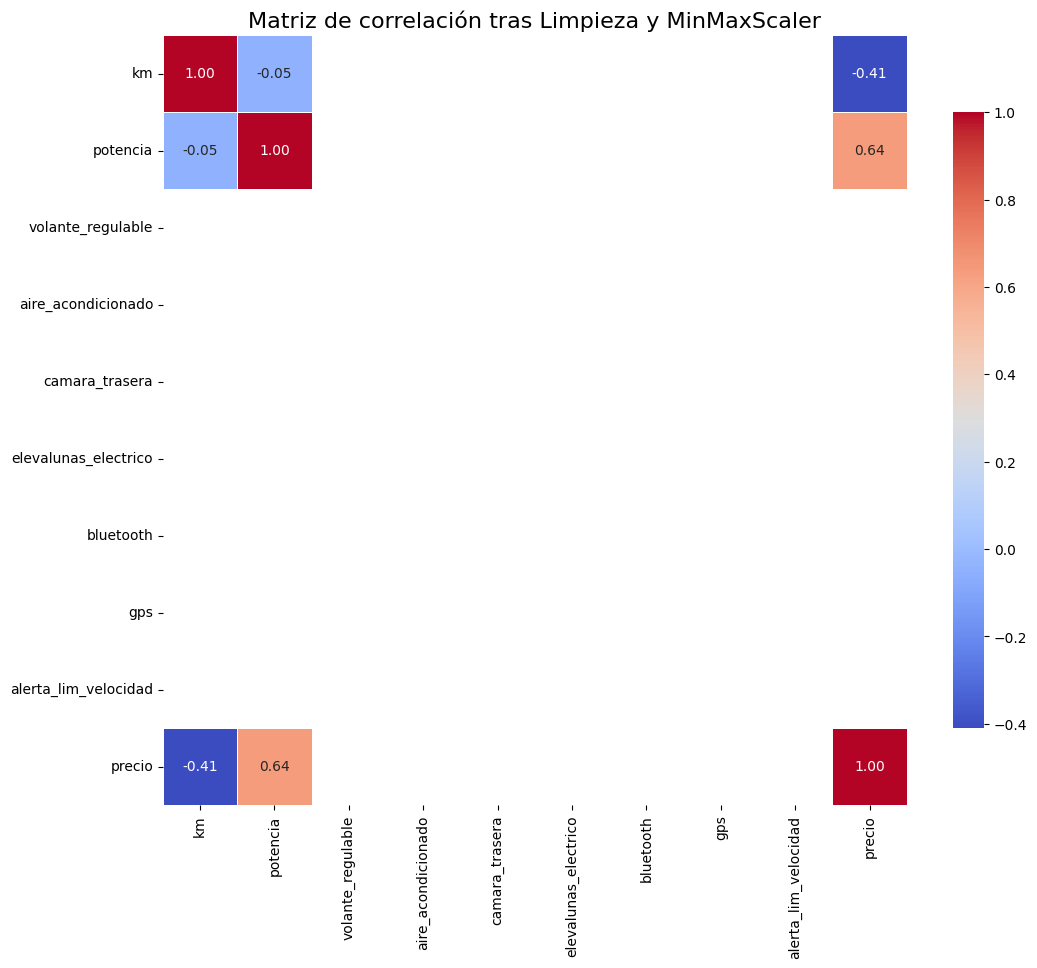

In [33]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Nota: Asumo que 'imdb' es tu DataFrame.
# La lista solo incluye columnas que deben ser numéricas
num_cols_to_corr = [
    'km', 'potencia', 'volante_regulable', 'aire_acondicionado',
    'camara_trasera', 'elevalunas_electrico', 'bluetooth', 'gps',
    'alerta_lim_velocidad', 'precio'
]

# --- 1. LIMPIEZA Y CONVERSIÓN ESTRICTA A NUMÉRICO ---
print("Iniciando limpieza y conversión estricta...")
for col in num_cols_to_corr:
    # Intentar convertir, forzando errores a NaN
    imdb[col] = pd.to_numeric(imdb[col], errors='coerce')
    # Imputar NaN (valores no convertibles) con 0 y convertir a float
    imdb[col] = imdb[col].fillna(0).astype(float)
print("Limpieza de datos completada.")


# --- 2. ESCALADO (MinMaxScaler) ---
scaler = MinMaxScaler()
imdb[num_cols_to_corr] = scaler.fit_transform(imdb[num_cols_to_corr])
print("Variables escaladas con éxito.")


# --- 4. VISUALIZACIÓN A: HEATMAP (Más grande para ver etiquetas) ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_scaled,
    annot=True,        # Mostrar el valor
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Matriz de correlación tras Limpieza y MinMaxScaler", fontsize=16)
plt.show()




Dataframe final

In [31]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4818 entries, 0 to 4842
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   modelo                       4818 non-null   float64
 1   km                           4818 non-null   float64
 2   potencia                     4818 non-null   float64
 3   volante_regulable            4818 non-null   float64
 4   aire_acondicionado           4818 non-null   float64
 5   camara_trasera               4818 non-null   float64
 6   elevalunas_electrico         4818 non-null   float64
 7   bluetooth                    4818 non-null   float64
 8   gps                          4818 non-null   float64
 9   alerta_lim_velocidad         4818 non-null   float64
 10  precio                       4818 non-null   float64
 11  tipo_gasolina_diesel         4818 non-null   bool   
 12  tipo_gasolina_electro        4818 non-null   bool   
 13  tipo_gasolina_hybrid_pe